In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [92]:
df = pd.read_csv("D:\git\python-data-analysis-lab\datasets\cars.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,?,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450


In [93]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    object 
 10  engine-size        205 non-null    int64  
 11  horsepower         205 non-null    object 
 12  city-mpg           205 non-null    int64  
 13  highway-mpg        205 non-null    int64  
 14  price              205 non-null    int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 24.2+ KB


In [94]:
df.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
body-style           0
drive-wheels         0
engine-location      0
width                0
height               0
engine-type          0
engine-size          0
horsepower           0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [95]:
df['normalized-losses'].value_counts()

?      41
161    11
91      8
150     7
134     6
128     6
104     6
85      5
94      5
65      5
102     5
74      5
168     5
103     5
95      5
106     4
93      4
118     4
148     4
122     4
83      3
125     3
154     3
115     3
137     3
101     3
119     2
87      2
89      2
192     2
197     2
158     2
81      2
188     2
194     2
153     2
129     2
108     2
110     2
164     2
145     2
113     2
256     1
107     1
90      1
231     1
142     1
121     1
78      1
98      1
186     1
77      1
Name: normalized-losses, dtype: int64

In [96]:
df['normalized-losses'].replace("?",np.nan, inplace=True)

In [97]:
df['normalized-losses'] = df['normalized-losses'].astype(float)

In [98]:
df['normalized-losses'].fillna(round(df['normalized-losses'].mean(),1), inplace=True)

In [99]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,122.0,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,122.0,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164.0,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164.0,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450


In [100]:
df['horsepower'].unique()

array(['111', '154', '102', '115', '110', '140', '160', '101', '121',
       '182', '48', '70', '68', '88', '145', '58', '76', '60', '86',
       '100', '78', '90', '176', '262', '135', '84', '64', '120', '72',
       '123', '155', '184', '175', '116', '69', '55', '97', '152', '200',
       '95', '142', '143', '207', '288', '?', '73', '82', '94', '62',
       '56', '112', '92', '161', '156', '52', '85', '114', '162', '134',
       '106'], dtype=object)

In [101]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors = 'coerce')

In [102]:
df['horsepower'].fillna(round(df['horsepower'].mean(),0), inplace=True)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    object 
 10  engine-size        205 non-null    int64  
 11  horsepower         205 non-null    float64
 12  city-mpg           205 non-null    int64  
 13  highway-mpg        205 non-null    int64  
 14  price              205 non-null    int64  
dtypes: float64(4), int64(5), object(6)
memory usage: 24.2+ KB


In [104]:
cars_cat = df.select_dtypes(object).columns
cars_cat

Index(['make', 'fuel-type', 'body-style', 'drive-wheels', 'engine-location',
       'engine-type'],
      dtype='object')

In [105]:
from sklearn.preprocessing import LabelEncoder

In [106]:
lbe = LabelEncoder()

In [107]:
for i in cars_cat:
    print(i)

make
fuel-type
body-style
drive-wheels
engine-location
engine-type


In [108]:
for i in cars_cat:
    df[i]=lbe.fit_transform(df[i])

In [109]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,122.0,0,1,0,2,0,64.1,48.8,0,130,111.0,21,27,13495
1,3,122.0,0,1,0,2,0,64.1,48.8,0,130,111.0,21,27,16500
2,1,122.0,0,1,2,2,0,65.5,52.4,5,152,154.0,19,26,16500
3,2,164.0,1,1,3,1,0,66.2,54.3,3,109,102.0,24,30,13950
4,2,164.0,1,1,3,0,0,66.4,54.3,3,136,115.0,18,22,17450


In [110]:
x= df.iloc[:,:-1]
x

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg
0,3,122.0,0,1,0,2,0,64.1,48.8,0,130,111.0,21,27
1,3,122.0,0,1,0,2,0,64.1,48.8,0,130,111.0,21,27
2,1,122.0,0,1,2,2,0,65.5,52.4,5,152,154.0,19,26
3,2,164.0,1,1,3,1,0,66.2,54.3,3,109,102.0,24,30
4,2,164.0,1,1,3,0,0,66.4,54.3,3,136,115.0,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,21,1,3,2,0,68.9,55.5,3,141,114.0,23,28
201,-1,95.0,21,1,3,2,0,68.8,55.5,3,141,160.0,19,25
202,-1,95.0,21,1,3,2,0,68.9,55.5,5,173,134.0,18,23
203,-1,95.0,21,0,3,2,0,68.9,55.5,3,145,106.0,26,27


In [111]:
y= df.iloc[:,-1]
y

0      13495
1      16500
2      16500
3      13950
4      17450
       ...  
200    16845
201    19045
202    21485
203    22470
204    22625
Name: price, Length: 205, dtype: int64

In [112]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.3,random_state=1)

In [113]:
len(xtrain),len(ytrain),len(xtest),len(ytest)

(143, 143, 62, 62)

In [114]:
linreg = LinearRegression()

In [115]:
linreg.fit(xtrain,ytrain)

LinearRegression()

In [116]:
ypred = linreg.predict(xtest)
ypred

array([ 6147.84196728,  6876.94807402,  5163.80846164,  6529.79192553,
        9097.54846833, 26360.3208709 ,  7459.89768787,   878.21437887,
        5143.88900492, 13519.6257496 , 15450.93058606, 14432.82705309,
       16383.40498746, 11141.23512041, 16456.4588046 , 13899.86889877,
        7470.86479737,  8822.18660532, 10871.94645117,  7575.71466139,
       10982.7202969 ,  6830.52007514, 13695.70996881,  6367.03291176,
       13729.614748  ,  8822.18660532, 15020.478675  ,  6519.05582477,
        4748.75013887,  9309.72977579,  8168.71319861, 14331.47900196,
       25640.23271405, 11910.76074116, 19763.98462653,  6561.95927003,
        8169.72797695, 30668.72328963,  9815.88325511, 16913.25842105,
        6488.34658028, 20293.80388985,  7703.70101986,  8440.35823684,
        8643.97737049,  7183.2222224 , 40496.49068905,  7556.36394943,
       17202.63501848, 18961.22672644, 26165.63344538, 16952.83948734,
       21835.40214346,  6217.21846787, 13103.59509522,  7263.5879863 ,
      

In [117]:
ytest

78      6669
97      7999
151     6338
44     10000
40     10295
       ...  
39      8845
110    13860
164     8238
56     11845
176    10898
Name: price, Length: 62, dtype: int64

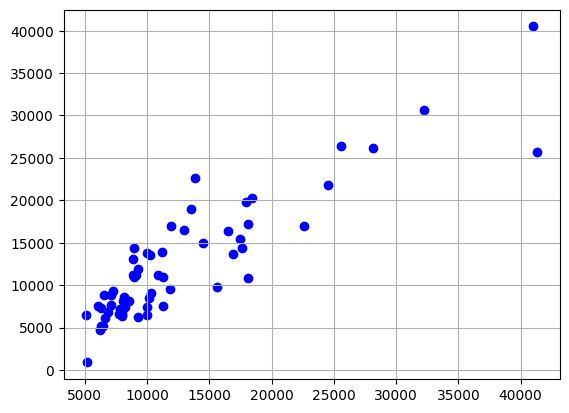

In [118]:
plt.scatter(ytest,ypred, color="blue")
plt.grid()
plt.show()

In [119]:
xpred = linreg.predict(xtrain)
xpred

array([16288.78089907, 15862.95149012,  5838.85225599,  7399.90019178,
        7448.21287589,  8340.19293437, 20112.98005262, 12044.05266806,
       10881.60200688, 29477.54680554, 15851.9576196 ,  5979.02408373,
       15128.40723229, 30633.48117389,  8026.17576096, 15238.00805431,
       22671.61292865,  7399.90019178,  6876.94807402,  5437.9556886 ,
        7448.21287589, 13729.614748  , 12275.26312398, 18782.75001558,
       34471.24861641, 19788.70481388, 16081.44896613,  6000.87989708,
       10695.97649555,  9851.0277694 ,  9007.88175727, 15773.38145604,
       18782.75001558, 15020.478675  , 17614.12396185,  8686.88081574,
        6484.6612469 , 19763.98462653, 10389.77691781,  8196.42991173,
       13575.80397841,  9258.49510772, 19763.98462653,  6848.33965708,
       20937.2084722 ,  5364.90343873, 14826.45121096, 18111.27200303,
        7364.42547833,  7448.21287589,  8643.97737049, 18407.97834397,
       27392.95983622, 10345.55762394,  5854.17491501, 20831.03092752,
      

In [120]:
ytrain

124    12764
181    15750
154     7898
53      6695
94      7299
       ...  
133    12170
137    18620
72     35056
140     7603
37      7895
Name: price, Length: 143, dtype: int64

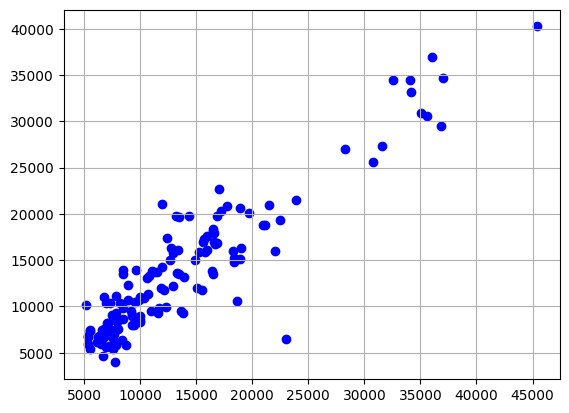

In [121]:
plt.scatter(ytrain,xpred, color="blue")
plt.grid()
plt.show()

In [122]:
r2_test = r2_score(ytest,ypred)
r2_test

0.7965544858354372

In [123]:
r2_train = r2_score(ytrain,xpred)
r2_train

0.8504568715278976

In [124]:
from sklearn.linear_model import Ridge, Lasso

In [125]:
rd = Ridge(alpha=10)

In [126]:
rd.fit(xtrain,ytrain)

Ridge(alpha=10)

In [127]:
rd_xpred = rd.predict(xtrain)
rd_xpred

array([17244.93225668, 15742.30444726,  6412.52840031,  7442.65317314,
        7693.89383865,  8345.22891759, 22584.57019251, 13455.67242853,
       10220.10872378, 29996.08365351, 15784.44269187,  6592.48946629,
       16165.71793457, 30295.22033721,  7554.93189129, 14875.02916334,
       21039.71296129,  7442.65317314,  6504.36197057,  4996.38409223,
        7693.89383865, 14606.84486933, 13094.11468165, 19624.88431983,
       25749.69137659, 21543.5888777 , 15754.71235545,  6803.97812773,
       11748.44875289,  9703.7989628 ,  9985.41145047, 15543.46097674,
       19624.88431983, 16235.40153821, 18185.5567988 ,  9303.24193094,
        6234.24821582, 18953.73839501, 10640.4315267 ,  8185.58852763,
       13464.03419632,  8444.1295292 , 18953.73839501,  7464.11643049,
       21099.76343746,  5260.14432204, 15826.67157724, 19820.85451977,
        7124.05699887,  7693.89383865,  9318.94684699, 20672.77965188,
       25790.64146927,  9931.88076238,  6406.91950172, 18903.77816785,
      

In [128]:
rd_ypred = rd.predict(xtest)
rd_ypred

array([ 5982.81883399,  6504.36197057,  6020.3234112 ,  6442.91868191,
       10091.12850472, 25394.99932823,  8453.96500922,  2467.80728061,
        6027.61497937, 13045.72148678, 15634.21646109, 16441.05562022,
       16093.75871277, 11235.68734221, 17526.84732232, 15237.50150567,
        7898.4067801 ,  8868.44357556, 13137.80080164,  8580.23241666,
       10736.83171116,  7109.15568313, 13480.96586203,  7103.2452427 ,
       14606.84486933,  8868.44357556, 16235.40153821,  7080.2647077 ,
        4676.9437883 ,  9112.57367298,  7442.62295116, 14937.27443369,
       27078.7905908 , 11874.78616143, 18953.73839501,  7064.55979164,
        8205.09509177, 30282.31987045, 10812.98306599, 15948.65803588,
        7625.13977858, 21137.86800623,  8327.87228431,  8069.90066954,
        9318.94684699,  7637.07350114, 41508.25005942,  8078.35781821,
       17113.14035895, 21205.33241406, 25948.34710187, 15303.59765874,
       22045.22944161,  5757.71047707, 12845.98067042,  7646.04221096,
      

In [129]:
r2_test = r2_score(ytest,rd_ypred)
r2_test

0.815032210450758

In [130]:
r2_train = r2_score(ytrain,rd_xpred)
r2_train

0.8109546206374152

In [132]:
la = Lasso(alpha=10)

In [133]:
la.fit(xtrain,ytrain)

Lasso(alpha=10)

In [134]:
la_xpred = la.predict(xtrain)
la_xpred

array([16317.27725654, 15921.23620048,  5894.52861265,  7415.33339487,
        7473.97159702,  8362.56109423, 20201.82642499, 12101.01344003,
       10864.00874278, 29507.10091185, 15852.52154987,  6001.08266743,
       15172.09949791, 30698.25937274,  8013.1454563 , 15160.36255826,
       22489.32305652,  7415.33339487,  6885.41921796,  5459.08292852,
        7473.97159702, 13776.55612147, 12340.54748355, 18851.7164523 ,
       33990.88987345, 19888.35857996, 16087.71212963,  6000.04357476,
       10765.89499019,  9864.2627204 ,  9053.7785804 , 15790.98530423,
       18851.7164523 , 15075.9055918 , 17665.66158836,  8731.68137576,
        6489.24684039, 19657.66922018, 10387.95804433,  8194.45415112,
       13600.20742299,  9141.40470679, 19657.66922018,  6895.37644571,
       20956.39901172,  5362.77350302, 14875.926859  , 18151.46793628,
        7344.69478461,  7473.97159702,  8688.44940245, 18480.9108274 ,
       27232.60208323, 10364.6972388 ,  5909.96860312, 20748.55706672,
      

In [135]:
la_ypred = la.predict(xtest)
la_ypred

array([ 6155.40249863,  6885.41921796,  5217.43431009,  6532.26732599,
        9157.95627819, 26228.88028482,  7498.99698447,   939.86628839,
        5197.36232248, 13520.80508459, 15465.18750909, 14507.81721918,
       16383.88476854, 11154.71431374, 16499.84326632, 13957.86481629,
        7501.28747426,  8804.79951456, 10980.88430463,  7642.30823192,
       11004.20286204,  6846.57558684, 13681.56708861,  6407.88849326,
       13776.55612147,  8804.79951456, 15075.9055918 ,  6481.23794913,
        4772.50060841,  9294.78937087,  8143.17824556, 14379.59672987,
       25730.01362201, 11966.10450899, 19657.66922018,  6524.46992243,
        8181.09230981, 30733.77135081,  9784.13620699, 16894.80553159,
        6523.12720363, 20345.08087458,  7654.28856148,  8452.03438468,
        8688.44940245,  7212.90784217, 40574.39339149,  7582.74609828,
       17207.15287441, 19084.70038475, 26044.68822718, 16882.4927255 ,
       21838.16000952,  6229.70351208, 13103.19157716,  7271.55962789,
      

In [136]:
r2_test = r2_score(ytest,la_ypred)
r2_test

0.798243348496918

In [137]:
r2_train = r2_score(ytrain,la_xpred)
r2_train

0.8503215916552948

In [138]:
for i in range(100,200):
    la=Lasso(alpha=i)
    la.fit(xtrain,ytrain)
    ypred = la.predict(xtest)
    train = la.score(xtrain,ytrain)
    test =la.score(xtest,ytest)
    print(f"i : {i}:- train: {train}, test: {test}")

i : 100:- train: 0.8372913548415435, test: 0.8090021821374433
i : 101:- train: 0.837033063279071, test: 0.80909267049436
i : 102:- train: 0.8367722038797116, test: 0.8091823221538317
i : 103:- train: 0.8365087764490943, test: 0.8092711373248026
i : 104:- train: 0.8362427803903202, test: 0.8093591164645104
i : 105:- train: 0.8359742156603912, test: 0.8094462596448548
i : 106:- train: 0.8357029872160338, test: 0.8095326262441969
i : 107:- train: 0.8354292840371239, test: 0.8096180971557301
i : 108:- train: 0.8351530115292964, test: 0.8097027326170216
i : 109:- train: 0.8348741696638744, test: 0.8097865326589195
i : 110:- train: 0.8345926568500504, test: 0.8098695559256965
i : 111:- train: 0.8343086758819214, test: 0.8099516842435875
i : 112:- train: 0.8340221254919853, test: 0.810032977225631
i : 113:- train: 0.8337330056479576, test: 0.810113434898173
i : 114:- train: 0.8334412081591293, test: 0.8101931149636479
i : 115:- train: 0.8331469490910792, test: 0.8102719010723352
i : 116:- tra